# Hyperparameter Tuning
**CS/DS 3262 Final Project — TikTok Binge-Session Classifier**

Each model is tuned with `GridSearchCV` nested inside 5-fold stratified cross-validation. The outer CV loop evaluates generalisation; the inner GridSearch selects hyperparameters. F1 is the optimisation metric throughout because the dataset is imbalanced (15.4% binge) and both false positives and false negatives carry cost.

| Model | Tuned parameter(s) | Search strategy |
|---|---|---|
| Logistic Regression | `C` (inverse regularisation strength) | Grid (7 values) |
| Random Forest | `max_depth`, `min_samples_leaf` | Grid (3 × 3 = 9 configs) |
| AdaBoost | `n_estimators`, `learning_rate` | Grid (3 × 3 = 9 configs) |

## 0. Setup & Data

In [1]:
import json, zipfile, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_validate, cross_val_score
)
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
SEED = 42
F1 = make_scorer(f1_score, zero_division=0)

# ── Rebuild session dataset ───────────────────────────────────────────────────
DATE_FMT = '%Y-%m-%d %H:%M:%S'
def parse_date(s):
    try: return datetime.strptime((s or '').strip(), DATE_FMT)
    except: return None

with zipfile.ZipFile('TikTok_Data_1776821537.zip') as z:
    with z.open('user_data_tiktok.json') as f:
        data = json.load(f)

act = data['Your Activity']; laf = data['Likes and Favorites']
rows = []
def add(source, primitive, records, date_key='Date'):
    for r in records:
        ts = parse_date(r.get(date_key) or r.get('date', ''))
        if ts: rows.append({'ts': ts, 'source': source, 'primitive': primitive})

add('watch',          'attention',  act.get('Watch History',  {}).get('VideoList', []))
add('search',         'intent',     act.get('Searches',       {}).get('SearchList', []))
add('share',          'social',     act.get('Share History',  {}).get('ShareHistoryList', []))
add('repost',         'social',     act.get('Reposts',        {}).get('RepostList', []))
add('comment',        'social',     data.get('Comment', {}).get('Comments', {}).get('CommentsList', []))
add('like',           'preference', laf.get('Likes', {}).get('ItemFavoriteList', []), date_key='date')
add('favorite_video', 'preference', laf.get('Favorite Videos', {}).get('FavoriteVideoList', []))
add('favorite_sound', 'preference', laf.get('Favorite Sounds', {}).get('FavoriteSoundList', []))

events = pd.DataFrame(rows).sort_values('ts').reset_index(drop=True)
SESSION_GAP = timedelta(minutes=30)
sids = [0]
for i in range(1, len(events)):
    sids.append(sids[-1] + (1 if events.loc[i,'ts'] - events.loc[i-1,'ts'] > SESSION_GAP else 0))
events['session_id'] = sids

def extract_features(grp):
    n = len(grp); duration = (grp['ts'].max() - grp['ts'].min()).total_seconds() / 60.0
    start = grp['ts'].min()
    cascade, last_search = 0, False
    for src in grp.sort_values('ts')['source']:
        if src == 'search': last_search = True
        elif src == 'watch' and last_search: cascade += 1; last_search = False
    return {'session_id': grp['session_id'].iloc[0], 'date': start.date(),
            'event_count': n, 'duration_min': round(duration, 4),
            'peak_epm': round(n / max(duration, 1.0), 4),
            'watch_share': round((grp['primitive']=='attention').mean(), 4),
            'search_share': round((grp['source']=='search').mean(), 4),
            'social_share': round((grp['primitive']=='social').mean(), 4),
            'pref_share': round((grp['primitive']=='preference').mean(), 4),
            'cascade_count': cascade, 'hour_of_day': start.hour,
            'day_of_week': start.weekday(),
            'has_search': int((grp['source']=='search').any()),
            'has_social': int((grp['primitive']=='social').any())}

sessions = pd.DataFrame([extract_features(g) for _, g in events.groupby('session_id')])
daily_counts = events.groupby(events['ts'].dt.date).size()
top10 = daily_counts.quantile(0.90); median_d = daily_counts.median()
binge_days = set(daily_counts[(daily_counts >= top10) & (daily_counts >= 2*median_d)].index)
sessions['binge'] = sessions['date'].apply(lambda d: int(d in binge_days))

sessions['hour_sin'] = np.sin(2 * np.pi * sessions['hour_of_day'] / 24)
sessions['hour_cos'] = np.cos(2 * np.pi * sessions['hour_of_day'] / 24)
sessions['dow_sin']  = np.sin(2 * np.pi * sessions['day_of_week'] / 7)
sessions['dow_cos']  = np.cos(2 * np.pi * sessions['day_of_week'] / 7)

SCALE_COLS   = ['event_count','duration_min','peak_epm','watch_share','search_share',
                'social_share','pref_share','cascade_count']
PASS_COLS    = ['has_search','has_social','hour_sin','hour_cos','dow_sin','dow_cos']
FEATURE_COLS = SCALE_COLS + PASS_COLS

X = sessions[FEATURE_COLS].values
y = sessions['binge'].values

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print(f'X: {X.shape}  |  binge rate: {y.mean():.1%}')
print('Setup complete.')

X: (7301, 14)  |  binge rate: 15.4%
Setup complete.


---
## 1. Logistic Regression — Tune `C`

`C` is the inverse of regularisation strength: small `C` = strong regularisation (high bias, low variance); large `C` = weak regularisation (low bias, high variance). The default `C=1.0` is a reasonable starting point but may underfit or overfit depending on the feature scale and sample size.

**Grid:** `C ∈ {0.001, 0.01, 0.1, 0.5, 1, 10, 100}` — seven values spanning four orders of magnitude.  
**Selection criterion:** mean F1 across 3 inner folds.

In [2]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=SEED
    )),
])

lr_grid = {'clf__C': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0]}

lr_search = GridSearchCV(
    lr_pipe, lr_grid, scoring=F1,
    cv=inner_cv, refit=True, n_jobs=-1, return_train_score=True
)

t0 = time.time()
lr_search.fit(X, y)
print(f'Grid search complete in {time.time()-t0:.1f}s')
print(f'Best C        : {lr_search.best_params_["clf__C"]}')
print(f'Best inner F1 : {lr_search.best_score_:.4f}')

lr_cv_results = pd.DataFrame(lr_search.cv_results_)
lr_display = lr_cv_results[['param_clf__C','mean_train_score','mean_test_score','std_test_score']].copy()
lr_display.columns = ['C','Train F1 (mean)','Val F1 (mean)','Val F1 (std)']
lr_display = lr_display.sort_values('C').round(4)
lr_display

Grid search complete in 2.0s
Best C        : 0.001
Best inner F1 : 0.8828


,C,Train F1 (mean),Val F1 (mean),Val F1 (std)
0,0.001,0.8831,0.8828,0.0140
1,0.010,0.8705,0.8710,0.0101
2,0.100,0.8669,0.8656,0.0084
3,0.500,0.8758,0.8701,0.0093
4,1.000,0.8794,0.8743,0.0100
5,10.000,0.8771,0.8750,0.0083
6,100.000,0.8745,0.8751,0.0094


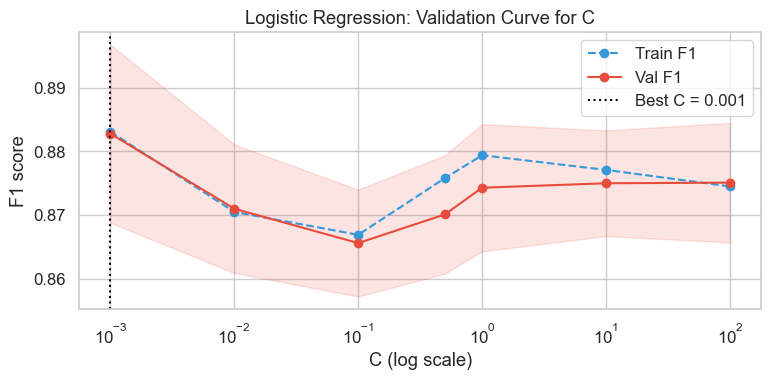

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lr_display['C'], lr_display['Train F1 (mean)'], 'o--', label='Train F1', color='#3498db')
ax.semilogx(lr_display['C'], lr_display['Val F1 (mean)'],   'o-',  label='Val F1',   color='#e74c3c')
ax.fill_between(lr_display['C'],
                lr_display['Val F1 (mean)'] - lr_display['Val F1 (std)'],
                lr_display['Val F1 (mean)'] + lr_display['Val F1 (std)'],
                alpha=0.15, color='#e74c3c')
ax.axvline(lr_search.best_params_['clf__C'], color='black', linestyle=':', linewidth=1.5,
           label=f'Best C = {lr_search.best_params_["clf__C"]}')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('F1 score')
ax.set_title('Logistic Regression: Validation Curve for C')
ax.legend()
plt.tight_layout()
plt.savefig('plot_tuning_lr.png', dpi=150)
plt.show()

---
## 2. Random Forest — Tune `max_depth` and `min_samples_leaf`

`max_depth` controls tree depth (deeper = more complex, higher variance). `min_samples_leaf` sets the minimum samples per leaf node, acting as implicit regularisation (larger = smoother boundaries). These two interact: a very deep tree with small leaves can memorise training data.

**Grid:** `max_depth ∈ {5, 15, None}` × `min_samples_leaf ∈ {1, 5, 20}` = 9 configurations.  
**Selection criterion:** mean F1 across 3 inner folds.

In [4]:
rf_pipe = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
    )),
])

rf_grid = {
    'clf__max_depth':       [5, 15, None],
    'clf__min_samples_leaf': [1, 5, 20],
}

rf_search = GridSearchCV(
    rf_pipe, rf_grid, scoring=F1,
    cv=inner_cv, refit=True, n_jobs=-1, return_train_score=True
)

t0 = time.time()
rf_search.fit(X, y)
print(f'Grid search complete in {time.time()-t0:.1f}s')
print(f'Best params   : {rf_search.best_params_}')
print(f'Best inner F1 : {rf_search.best_score_:.4f}')

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_display = rf_cv_results[[
    'param_clf__max_depth','param_clf__min_samples_leaf',
    'mean_train_score','mean_test_score','std_test_score'
]].copy()
rf_display.columns = ['max_depth','min_samples_leaf','Train F1','Val F1','Val std']
rf_display = rf_display.sort_values('Val F1', ascending=False).round(4)
rf_display

Grid search complete in 1.4s
Best params   : {'clf__max_depth': 5, 'clf__min_samples_leaf': 20}
Best inner F1 : 0.8870


,max_depth,min_samples_leaf,Train F1,Val F1,Val std
2,5,20,0.8921,0.8870,0.0067
1,5,5,0.8960,0.8869,0.0095
0,5,1,0.8979,0.8869,0.0102
7,None,5,0.9124,0.8868,0.0102
4,15,5,0.9114,0.8867,0.0114
8,None,20,0.8930,0.8850,0.0042
5,15,20,0.8928,0.8841,0.0037
3,15,1,0.9767,0.8799,0.0162
6,None,1,0.9762,0.8723,0.0158


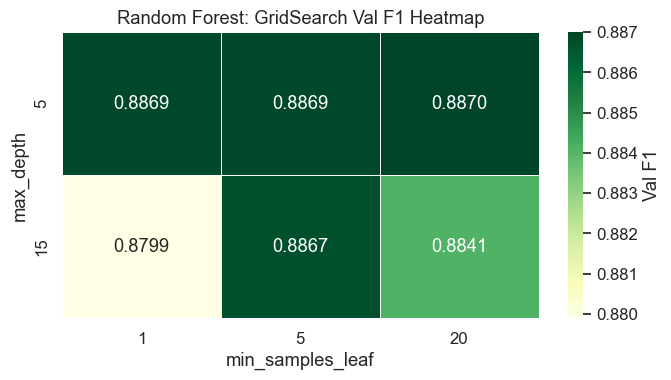

In [5]:
pivot = rf_cv_results.pivot_table(
    index='param_clf__max_depth',
    columns='param_clf__min_samples_leaf',
    values='mean_test_score'
).round(4)
pivot.index = [str(v) for v in pivot.index]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Val F1'})
ax.set_title('Random Forest: GridSearch Val F1 Heatmap')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('plot_tuning_rf.png', dpi=150)
plt.show()

---
## 3. AdaBoost — Tune `n_estimators` and `learning_rate`

`n_estimators` is the number of weak learners in the sequence — more estimators reduce bias but increase training time and risk overfitting noisy labels. `learning_rate` shrinks each tree's contribution; lower rates require more estimators to converge but generalise better.

**Grid:** `n_estimators ∈ {100, 200, 400}` × `learning_rate ∈ {0.1, 0.5, 1.0}` = 9 configurations.  
**Selection criterion:** mean F1 across 3 inner folds.

In [6]:
ada_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        random_state=SEED
    )),
])

ada_grid = {
    'clf__n_estimators': [100, 200, 400],
    'clf__learning_rate': [0.1, 0.5, 1.0],
}

ada_search = GridSearchCV(
    ada_pipe, ada_grid, scoring=F1,
    cv=inner_cv, refit=True, n_jobs=-1, return_train_score=True
)

t0 = time.time()
ada_search.fit(X, y)
print(f'Grid search complete in {time.time()-t0:.1f}s')
print(f'Best params   : {ada_search.best_params_}')
print(f'Best inner F1 : {ada_search.best_score_:.4f}')

ada_cv_results = pd.DataFrame(ada_search.cv_results_)
ada_display = ada_cv_results[[
    'param_clf__n_estimators','param_clf__learning_rate',
    'mean_train_score','mean_test_score','std_test_score'
]].copy()
ada_display.columns = ['n_estimators','learning_rate','Train F1','Val F1','Val std']
ada_display = ada_display.sort_values('Val F1', ascending=False).round(4)
ada_display

Grid search complete in 2.0s
Best params   : {'clf__learning_rate': 1.0, 'clf__n_estimators': 400}
Best inner F1 : 0.8897


,n_estimators,learning_rate,Train F1,Val F1,Val std
8,400,1.0,0.8902,0.8897,0.0155
5,400,0.5,0.8898,0.8895,0.0151
4,200,0.5,0.8895,0.8890,0.0146
7,200,1.0,0.8897,0.8888,0.0143
3,100,0.5,0.8894,0.8885,0.0144
6,100,1.0,0.8896,0.8874,0.0148
2,400,0.1,0.8882,0.8856,0.0137
0,100,0.1,0.8834,0.8832,0.0131
1,200,0.1,0.8834,0.8832,0.0131


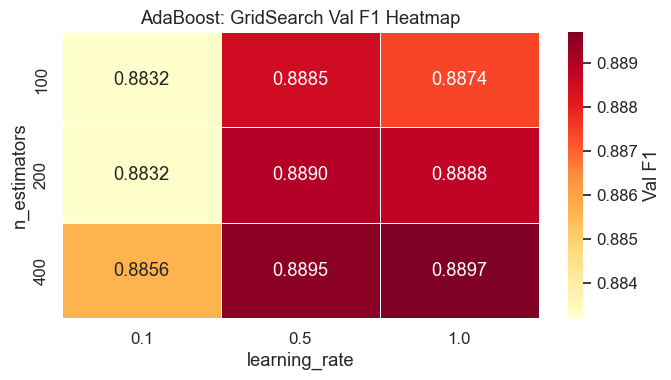

In [7]:
pivot_ada = ada_cv_results.pivot_table(
    index='param_clf__n_estimators',
    columns='param_clf__learning_rate',
    values='mean_test_score'
).round(4)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_ada, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Val F1'})
ax.set_title('AdaBoost: GridSearch Val F1 Heatmap')
ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
plt.tight_layout()
plt.savefig('plot_tuning_ada.png', dpi=150)
plt.show()

---
## 4. Outer CV Evaluation — Tuned Models

Each tuned estimator (best params from GridSearch) is now evaluated in the outer 5-fold loop to get unbiased generalisation estimates. The `GridSearchCV` object with `refit=True` is passed directly as the estimator — sklearn re-runs the inner search on each outer training fold, so there is no data leakage.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def auc_scorer(clf, X, y):
    return roc_auc_score(y, clf.predict_proba(X)[:, 1])

full_scoring = {
    'accuracy':  make_scorer(accuracy_score),
    'f1':        make_scorer(f1_score,        zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score,    zero_division=0),
    'roc_auc':   auc_scorer,
}
metrics = ['accuracy','f1','precision','recall','roc_auc']

# Rebuild fresh search objects for the nested outer CV (avoid leakage from earlier fit)
lr_nested = GridSearchCV(lr_pipe, lr_grid, scoring=F1, cv=inner_cv, refit=True, n_jobs=-1)
rf_nested = GridSearchCV(rf_pipe, rf_grid, scoring=F1, cv=inner_cv, refit=True, n_jobs=-1)
ada_nested = GridSearchCV(ada_pipe, ada_grid, scoring=F1, cv=inner_cv, refit=True, n_jobs=-1)

print('Running nested CV (this takes ~60s)...')
t0 = time.time()
lr_outer  = cross_validate(lr_nested,  X, y, cv=outer_cv, scoring=full_scoring, n_jobs=-1)
rf_outer  = cross_validate(rf_nested,  X, y, cv=outer_cv, scoring=full_scoring, n_jobs=-1)
ada_outer = cross_validate(ada_nested, X, y, cv=outer_cv, scoring=full_scoring, n_jobs=-1)
print(f'Done in {time.time()-t0:.1f}s')

results = {
    'LR (tuned)':  {m: lr_outer[f'test_{m}']  for m in metrics},
    'RF (tuned)':  {m: rf_outer[f'test_{m}']  for m in metrics},
    'Ada (tuned)': {m: ada_outer[f'test_{m}'] for m in metrics},
}

summary = pd.DataFrame({
    name: {m: vals[m].mean() for m in metrics}
    for name, vals in results.items()
}).T.round(4)
summary.columns = ['Accuracy','F1','Precision','Recall','AUC']
print('\nOuter 5-fold CV means (nested GridSearchCV):')
summary

Running nested CV (this takes ~60s)...


Done in 14.9s

Outer 5-fold CV means (nested GridSearchCV):


,Accuracy,F1,Precision,Recall,AUC
LR (tuned),0.9675,0.8830,0.9871,0.7993,0.9429
RF (tuned),0.9679,0.8881,0.9558,0.8305,0.9442
Ada (tuned),0.9686,0.8874,0.9862,0.8073,0.9436


In [9]:
# Per-fold detail
print('Per-fold F1 scores:')
for name, folds in results.items():
    vals = folds['f1']
    print(f'  {name:<14}: {"  ".join(f"{v:.3f}" for v in vals)}  mean={vals.mean():.3f}  std={vals.std():.3f}')

Per-fold F1 scores:
  LR (tuned)    : 0.896  0.860  0.878  0.900  0.881  mean=0.883  std=0.014
  RF (tuned)    : 0.900  0.873  0.881  0.903  0.883  mean=0.888  std=0.012
  Ada (tuned)   : 0.904  0.869  0.876  0.905  0.883  mean=0.887  std=0.015


## 5. Summary: Best Hyperparameters

In [10]:
tuning_summary = pd.DataFrame([
    {'Model': 'Logistic Regression',
     'Parameter': 'C',
     'Grid': '[0.001, 0.01, 0.1, 0.5, 1, 10, 100]',
     'Best value': lr_search.best_params_['clf__C'],
     'Inner CV F1': round(lr_search.best_score_, 4)},
    {'Model': 'Random Forest',
     'Parameter': 'max_depth / min_samples_leaf',
     'Grid': '[5, 15, None] x [1, 5, 20]',
     'Best value': f"depth={rf_search.best_params_['clf__max_depth']}, leaf={rf_search.best_params_['clf__min_samples_leaf']}",
     'Inner CV F1': round(rf_search.best_score_, 4)},
    {'Model': 'AdaBoost',
     'Parameter': 'n_estimators / learning_rate',
     'Grid': '[100, 200, 400] x [0.1, 0.5, 1.0]',
     'Best value': f"n={ada_search.best_params_['clf__n_estimators']}, lr={ada_search.best_params_['clf__learning_rate']}",
     'Inner CV F1': round(ada_search.best_score_, 4)},
])
tuning_summary

,Model,Parameter,Grid,Best value,Inner CV F1
0,Logistic Regression,C,"[0.001, 0.01, 0.1, 0.5, 1, 10, 100]",0.001,0.8828
1,Random Forest,max_depth / min_samples_leaf,"[5, 15, None] x [1, 5, 20]","depth=5, leaf=20",0.8870
2,AdaBoost,n_estimators / learning_rate,"[100, 200, 400] x [0.1, 0.5, 1.0]","n=400, lr=1.0",0.8897


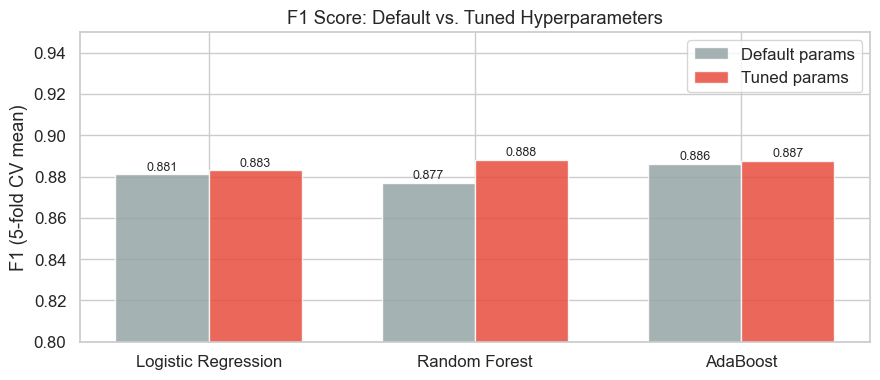

In [11]:
# Comparison bar chart: default vs tuned F1
default_f1 = {'Logistic Regression': 0.881, 'Random Forest': 0.877, 'AdaBoost': 0.886}
tuned_f1   = {name: results[name]['f1'].mean()
              for name in ['LR (tuned)','RF (tuned)','Ada (tuned)']}

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3); w = 0.35
labels = ['Logistic Regression','Random Forest','AdaBoost']
ax.bar(x - w/2, list(default_f1.values()), w, label='Default params', color='#95a5a6', alpha=0.85)
ax.bar(x + w/2, list(tuned_f1.values()),   w, label='Tuned params',   color='#e74c3c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.8, 0.95)
ax.set_ylabel('F1 (5-fold CV mean)')
ax.set_title('F1 Score: Default vs. Tuned Hyperparameters')
ax.legend()
for i, (d, t) in enumerate(zip(default_f1.values(), tuned_f1.values())):
    ax.text(i - w/2, d + 0.002, f'{d:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, t + 0.002, f'{t:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_tuning_comparison.png', dpi=150)
plt.show()